In [2]:
#1导入库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family']=['SimHei']



In [8]:
#2导入数据
df=pd.read_csv('data/house_sales.csv') 
#3数据概览
print(df.head())
df.info()

  city              address area     floor    name price province rooms  \
0   合肥   龙岗-临泉东路和王岗大道交叉口东南角  90㎡  中层（共18层）    圣地亚哥  128万       安徽  3室2厅   
1   合肥   龙岗-临泉东路和王岗大道交叉口东南角  90㎡  中层（共18层）    圣地亚哥  128万       安徽  3室2厅   
2   合肥      生态公园-淮海大道与大众路交口  95㎡  中层（共18层）  正荣·悦都荟  132万       安徽  3室2厅   
3   合肥      生态公园-淮海大道与大众路交口  95㎡  中层（共18层）  正荣·悦都荟  132万       安徽  3室2厅   
4   合肥  撮镇-文一名门金隅裕溪路与东风大道交口  37㎡  中层（共22层）  文一名门金隅   32万       安徽  2室1厅   

  toward      unit    year                                       origin_url  
0    南北向  14222元/㎡  2013年建  https://hf.esf.fang.com/chushou/3_404230646.htm  
1    南北向  14222元/㎡  2013年建  https://hf.esf.fang.com/chushou/3_404230646.htm  
2     南向  13895元/㎡  2019年建  https://hf.esf.fang.com/chushou/3_404304901.htm  
3     南向  13895元/㎡  2019年建  https://hf.esf.fang.com/chushou/3_404304901.htm  
4    南北向   8649元/㎡  2017年建  https://hf.esf.fang.com/chushou/3_404372096.htm  
<class 'pandas.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (

In [16]:
#3数据清洗
#df.drop(columns='origin_url',inplace=True)
df.head()
df.isna().sum()
df.dropna(inplace=True)
df.isna().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 28104 entries, 0 to 106088
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   city      28104 non-null  str  
 1   address   28104 non-null  str  
 2   area      28104 non-null  str  
 3   floor     28104 non-null  str  
 4   name      28104 non-null  str  
 5   price     28104 non-null  str  
 6   province  28104 non-null  str  
 7   rooms     28104 non-null  str  
 8   toward    28104 non-null  str  
 9   unit      28104 non-null  str  
 10  year      28104 non-null  str  
dtypes: str(11)
memory usage: 2.6 MB


In [28]:
df.head()
df['area'] = df['area'].str.replace('㎡','').astype(float)
df['price'] = df['price'].str.replace('万','').astype(float)
df['unit'] = df['unit'].str.replace('元/㎡','').astype(float)
df['floor'] = df['floor'].str[0:2]
df.head()

AttributeError: Can only use .str accessor with string values, not floating

In [32]:
df.head()
#df['year'] = df['year'].str.replace('年建','').astype(int)
df['year'] = df['year'].astype(int)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017
6,合肥,龙岗-长江东路与和县里交口,50.0,高层,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012


In [34]:
df['toward'] = df['toward'].astype('category')
df.info()

<class 'pandas.DataFrame'>
Index: 28104 entries, 0 to 106088
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   city      28104 non-null  str     
 1   address   28104 non-null  str     
 2   area      28104 non-null  float64 
 3   floor     28104 non-null  str     
 4   name      28104 non-null  str     
 5   price     28104 non-null  float64 
 6   province  28104 non-null  str     
 7   rooms     28104 non-null  str     
 8   toward    28104 non-null  category
 9   unit      28104 non-null  float64 
 10  year      28104 non-null  int64   
dtypes: category(1), float64(3), int64(1), str(6)
memory usage: 2.4 MB


In [ ]:
#数据特征构造
#直辖市
df.head()
def fun1(str1):
    if str1 in ['北京','上海','天津','重庆']:
        return True
    else:
        return False
df['iszxs'] = df['city'].apply(fun1)

def fun2(str2):
    return True if str2 in ['北京','上海','天津','重庆'] else False
df['iszxs'] = df['city'].apply(lambda x : fun2(x))

df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,iszxs
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,False
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,False
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,False
6,合肥,龙岗-长江东路与和县里交口,50.0,高层,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,False
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,False


In [40]:
df['bedrooms'] = df['rooms'].str[0:1].astype(int)
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,iszxs,bedrooms,livingrooms
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,False,3,2
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,False,3,2
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,False,2,1
6,合肥,龙岗-长江东路与和县里交口,50.0,高层,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,False,2,1
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,False,4,2


In [41]:
df['building_age'] = 2025 - df['year']
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,iszxs,bedrooms,livingrooms,building_age
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,False,3,2,12
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,False,3,2,6
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,False,2,1,8
6,合肥,龙岗-长江东路与和县里交口,50.0,高层,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,False,2,1,6
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,False,4,2,13


                  area     price      unit  building_age
area          1.000000  0.420423  0.044427     -0.065717
price         0.420423  1.000000  0.781600      0.084730
unit          0.044427  0.781600  1.000000      0.201435
building_age -0.065717  0.084730  0.201435      1.000000


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

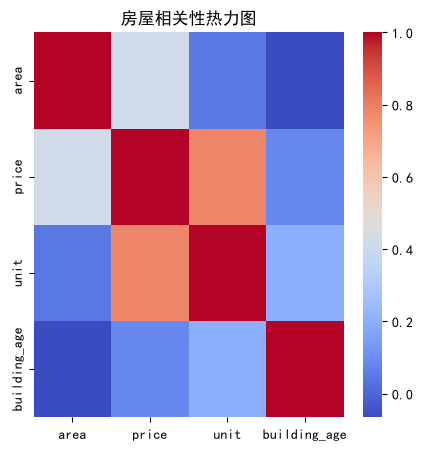

In [51]:
a = df[['area','price','unit','building_age']].corr()
print(a)
a['price'].sort_values(ascending=False)[1:]
plt.figure(figsize=(5,5))
import seaborn as sns
sns.heatmap(a,cmap='coolwarm')
plt.title('房屋相关性热力图')
plt.tight_layout

<class 'pandas.DataFrame'>
Index: 27439 entries, 0 to 106088
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   city          27439 non-null  str     
 1   address       27439 non-null  str     
 2   area          27439 non-null  float64 
 3   floor         27439 non-null  str     
 4   name          27439 non-null  str     
 5   price         27439 non-null  float64 
 6   province      27439 non-null  str     
 7   rooms         27439 non-null  str     
 8   toward        27439 non-null  category
 9   unit          27439 non-null  float64 
 10  year          27439 non-null  int64   
 11  iszxs         27439 non-null  bool    
 12  bedrooms      27439 non-null  int64   
 13  livingrooms   27439 non-null  int64   
 14  building_age  27439 non-null  int64   
dtypes: bool(1), category(1), float64(3), int64(4), str(6)
memory usage: 3.0 MB
<class 'pandas.DataFrame'>
Index: 27439 entries, 0 to 106088
Data columns (tot

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

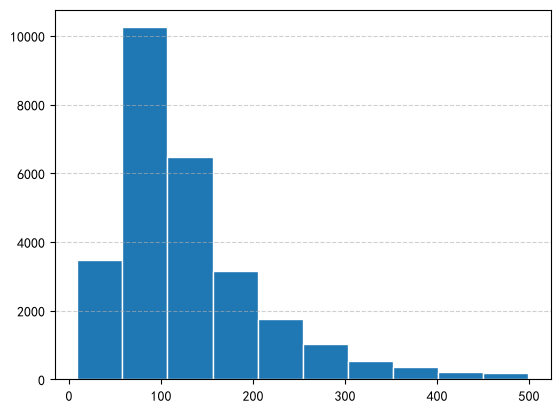

In [80]:
df.describe()
plt.subplot(111)
df.info()
df = df[df['price']<500]
df.info()
plt.hist(df['price'],bins=10,edgecolor='white')
plt.grid(axis='y',alpha=0.6,linestyle='--')
plt.tight_layout

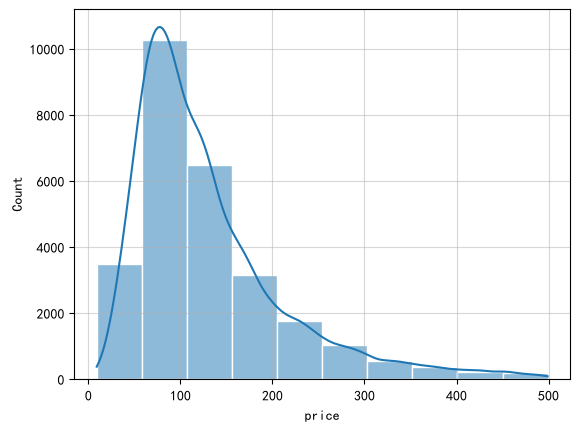

In [84]:
sns.histplot(data=df,x='price',bins=10,kde=True,edgecolor='white')
plt.grid(True,alpha=0.5)